In [54]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Visualization and Output Settings
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

data_path = "C:/Users/ghost/OneDrive/Desktop/projects/hotel-booking-ab-testing\data/raw/hotel_booking_ab_testing.csv"
df = pd.read_csv(data_path)

print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
df.head()

Total rows: 30,000
Total columns: 8


,user_id,booking_date,group,hotel_id,booked,cancelled,check_in_date,check_out_date
0,10905,11/01/2026,Control,3008,0,0,15/01/2026,17/01/2026
1,23390,24/01/2026,Treatment,3007,0,0,27/01/2026,31/01/2026
2,20770,02/01/2026,Treatment,3009,1,0,07/01/2026,08/01/2026
3,23422,26/01/2026,Treatment,3007,0,0,30/01/2026,03/02/2026
4,37020,29/01/2026,Control,3003,0,0,03/02/2026,04/02/2026


In [55]:
# Data types and null analysis
data_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing Ratio (%)": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})
display(data_summary)

,Data Type,Missing Values,Missing Ratio (%),Unique Values
user_id,int64,0,0.0,30000
booking_date,str,0,0.0,31
group,str,0,0.0,2
hotel_id,int64,0,0.0,10
booked,int64,0,0.0,2
cancelled,int64,0,0.0,2
check_in_date,str,0,0.0,37
check_out_date,str,0,0.0,41


In [56]:
# Total rows vs. unique users
total_rows = len(df)
unique_users = df["user_id"].nunique()
print(f"Total rows: {total_rows:,} | Unique users number: {unique_users:,}")

# Are there any users present in both groups?
users_per_group = df.groupby("user_id")["group"].nunique()
contaminated_users = users_per_group[users_per_group > 1].index

print(f"Number of contaminated users in both groups: {len(contaminated_users)}")

if len(contaminated_users) > 0:
    print("WARNING: Contaminated users have been detected. They must be cleaned from the data.")
    df = df[~df[user_id].isin(contaminated_users)]
    print(f"Total rows after cleaning: {len(df)}")
else:
    print("There is no contamination.")

Total rows: 30,000 | Unique users number: 30,000
Number of contaminated users in both groups: 0
There is no contamination.


In [57]:
# Group distributions
group_counts = df["group"].value_counts()
print("Observed User Counts:")
print(group_counts)

# Expected ratios (50/50)
total_participants = group_counts.sum()
expected_counts = [total_participants * 0.5, total_participants * 0.5]

# Chi-Square Test
chi2_stat, p_val_srm = stats.chisquare(f_obs=group_counts, f_exp=expected_counts)

print("\n--- SRM Test Results ---")
print(f"Chi-Square Stat: {chi2_stat:.4f}")
print(f"p-value: {p_val_srm:.4f}")

alpha = 0.01
if p_val_srm < alpha:
    print("ATTENTION: SRM detected (p < 0.01)! There is a bias in traffic distribution or a technical leak.")
else:
    print("VALID: No SRM (p >= 0.01). Traffic is distributed randomly and at the targeted ratio (50%/50%).")

Observed User Counts:
group
Control      15000
Treatment    15000
Name: count, dtype: int64

--- SRM Test Results ---
Chi-Square Stat: 0.0000
p-value: 1.0000
VALID: No SRM (p >= 0.01). Traffic is distributed randomly and at the targeted ratio (50%/50%).


In [58]:
# Summary of General Metrics
metrics_summary = df.groupby("group").agg(
    total_users=("user_id", "count"),
    booked_users=("booked", "sum"),
    cancelled_users=("cancelled", "sum")
)

# Rates
metrics_summary["conversion_rate (%)"] = (metrics_summary["booked_users"] / metrics_summary["total_users"]) * 100
# Cancellation rate: The cancellation rate among those who made a reservation.
metrics_summary["cancellation_rate_among_booked (%)"] = (metrics_summary["cancelled_users"] / metrics_summary["booked_users"]) * 100
# Net successful bookings (Bookings that were not cancelled)
metrics_summary["net_successful_bookings"] = metrics_summary["booked_users"] - metrics_summary["cancelled_users"]
metrics_summary["net_success_rate (%)"] = (metrics_summary["net_successful_bookings"] / metrics_summary["total_users"]) * 100

display(metrics_summary.round(3))

,total_users,booked_users,cancelled_users,conversion_rate (%),cancellation_rate_among_booked (%),net_successful_bookings,net_success_rate (%)
group,,,,,,,
Control,15000,1990,266,13.267,13.367,1724,11.493
Treatment,15000,2448,469,16.320,19.158,1979,13.193


In [59]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# Separate the numbers
control_users = metrics_summary.loc["Control", "total_users"]
treatment_users = metrics_summary.loc["Treatment", "total_users"]

control_booked = metrics_summary.loc["Control", "booked_users"]
treatment_booked = metrics_summary.loc["Treatment", "booked_users"]

# Conversion Z-Test
count_booked = [treatment_booked, control_booked]
nobs_booked = [treatment_users, control_users]

z_stat_conv, p_val_conv = proportions_ztest(count_booked, nobs_booked, alternative = "two-sided")
ci_low_conv, ci_upp_conv = confint_proportions_2indep(treatment_booked, treatment_users, control_booked, control_users, method='wald')

print("--- CONVERSION RATE ---")
print(f"Z-Stat: {z_stat_conv:.4f}")
print(f"p-value: {p_val_conv:.4e}")
print(f"%95 Confidence Interval: [{ci_low_conv*100:.2f}%, {ci_upp_conv*100:.2f}%]")
if p_val_conv < 0.05:
    print("Decision: There is a statistically significant difference. (H0 rejected).")
else:
    print("Decision: There is not a statistically significant difference.")

# Cancellation Z-Test
control_canc = metrics_summary.loc["Control","cancelled_users"]
treatment_canc = metrics_summary.loc["Treatment","cancelled_users"]

count_canc = [treatment_canc, control_canc]
nobs_canc = [treatment_booked, control_booked]

z_stat_canc, p_val_canc = proportions_ztest(count_canc, nobs_canc, alternative = "two-sided")
ci_low_canc, ci_upp_canc = confint_proportions_2indep(treatment_canc, treatment_booked, control_canc, control_booked, method='wald')

print("\n--- CANCELLATION AMONG BOOKED ---")
print(f"Z-Stat: {z_stat_canc:.4f}")
print(f"p-value: {p_val_canc:.4e}")
print(f"%95 Confidence Interval: [{ci_low_canc*100:.2f}%, {ci_upp_canc*100:.2f}%]")
if p_val_canc < 0.05:
    print("Decision: There is a statistically significant difference in the cancellation rate.")
else:
    print("Decision: There is no significant difference in the cancellation rate.")

--- CONVERSION RATE ---
Z-Stat: 7.4479
p-value: 9.4823e-14
%95 Confidence Interval: [2.25%, 3.86%]
Decision: There is a statistically significant difference. (H0 rejected).

--- CANCELLATION AMONG BOOKED ---
Z-Stat: 5.1619
p-value: 2.4447e-07
%95 Confidence Interval: [3.63%, 7.95%]
Decision: There is a statistically significant difference in the cancellation rate.


In [60]:
# Z-Test based on net successful bookings,
control_net = metrics_summary.loc["Control","net_successful_bookings"]
treatment_net = metrics_summary.loc["Treatment","net_successful_bookings"]

z_stat_net, p_val_net = proportions_ztest([treatment_net, control_net],[treatment_users, control_users])
ci_low_net, ci_upp_net = confint_proportions_2indep(treatment_net, treatment_users, control_net, control_users, method="wald")

print("--- NET SUCCESFUL BOOKINGS ---")
print(f"Z-Stat: {z_stat_net:.4f}")
print(f"p-value: {p_val_net:.4e}")
print(f"%95 Confident Interval: [{ci_low_net*100:.2f}%, {ci_upp_net*100:.2f}%]")

--- NET SUCCESFUL BOOKINGS ---
Z-Stat: 4.4758
p-value: 7.6125e-06
%95 Confident Interval: [0.96%, 2.44%]


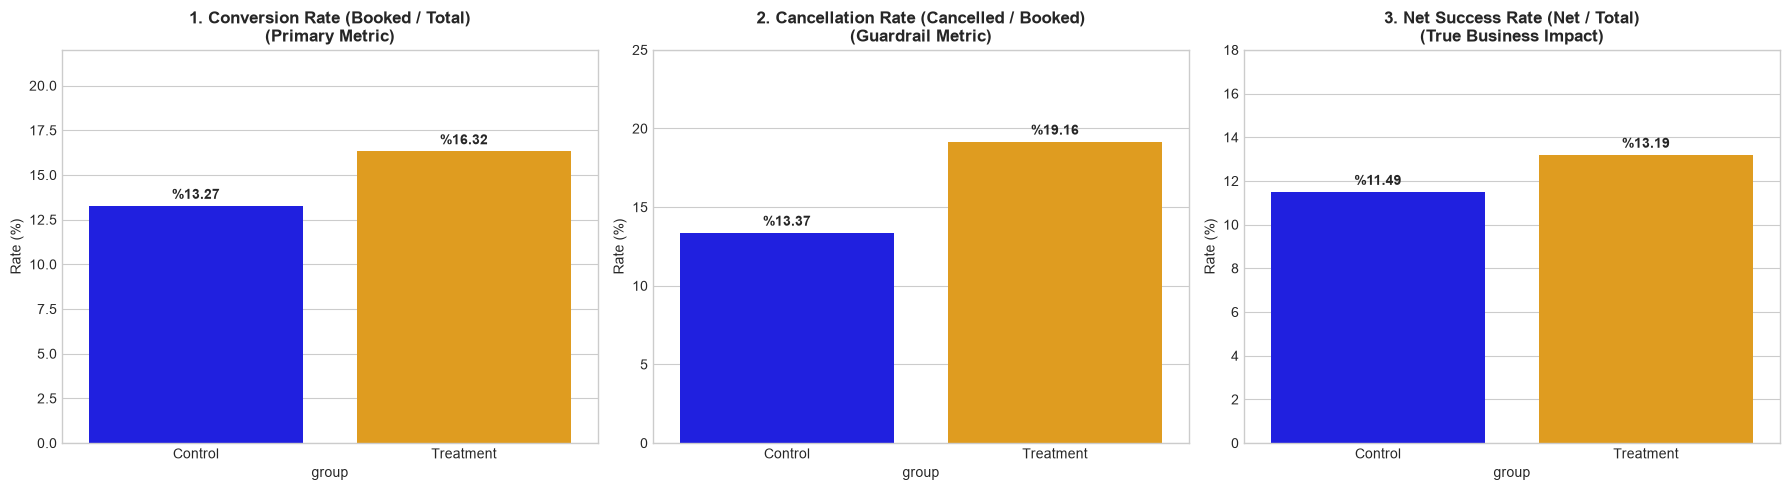

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {'Control': 'blue', 'Treatment': 'orange'}

sns.barplot(ax=axes[0], x=metrics_summary.index, y='conversion_rate (%)', data=metrics_summary, palette=palette)
sns.barplot(ax=axes[1], x=metrics_summary.index, y='cancellation_rate_among_booked (%)', data=metrics_summary, palette=palette)
sns.barplot(ax=axes[2], x=metrics_summary.index, y='net_success_rate (%)', data=metrics_summary, palette=palette)

titles = [
    '1. Conversion Rate (Booked / Total)\n(Primary Metric)',
    '2. Cancellation Rate (Cancelled / Booked)\n(Guardrail Metric)',
    '3. Net Success Rate (Net / Total)\n(True Business Impact)'
]
ylims = [(0, 22), (0, 25), (0, 18)]

for ax, title, ylim in zip(axes, titles, ylims):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Rate (%)')
    ax.set_ylim(ylim)
    
    for c in ax.containers:
        ax.bar_label(c, fmt='%%%.2f', padding=3, weight='bold')

plt.tight_layout()
plt.savefig("../reports_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

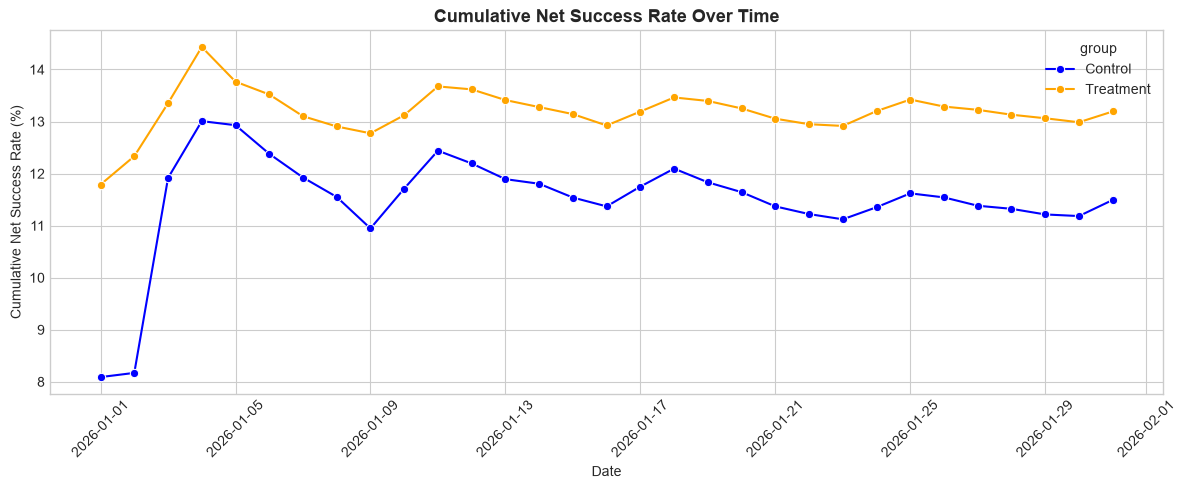

In [63]:
df['booking_date'] = pd.to_datetime(df['booking_date'], format="%d/%m/%Y")

daily_trend = df.groupby(['booking_date', 'group']).agg(
    total=('user_id', 'count'),
    net_success=('booked', lambda x: (x == 1).sum() - df.loc[x.index, 'cancelled'].sum())
).reset_index()

daily_trend['cum_total'] = daily_trend.groupby('group')['total'].cumsum()
daily_trend['cum_net_success'] = daily_trend.groupby('group')['net_success'].cumsum()
daily_trend['cum_net_rate'] = (daily_trend['cum_net_success'] / daily_trend['cum_total']) * 100

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='booking_date', y='cum_net_rate', hue='group', palette=palette, marker='o')
plt.title('Cumulative Net Success Rate Over Time', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Net Success Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports_trend", dpi=300, bbox_inches='tight')
plt.show()